# 🧪 The Capstone: A/B Testing & Bootstrapping
### Stage 8B: Running a Real Experiment, Start to Finish  |  ⏱️ ~40-minute session

---

**Recap:** You now have every tool: hypothesis testing (Stage 1), assumption checks (Stage 2), t-tests/ANOVA (Stage 3), non-parametric alternatives (Stage 4), Chi-Square (Stage 5), correlation/regression (Stage 6-7), and effect size/power/multiple-testing (Stage 8A). This session is where it all clicks into one workflow — because **A/B testing is not a new test.** It's a *framework* that assembles tools you already know, in a specific order, to answer one business question.

### The one question A/B testing answers
> *"Did the change we made actually cause the improvement we're seeing — or could this just be random noise?"*

### Session map (suggested pacing)

| Time | Topic |
|---|---|
| 0:00 – 0:06 | The A/B testing framework, end to end |
| 0:06 – 0:20 | Full worked example: designing, running, and analyzing a real A/B test |
| 0:20 – 0:26 | The classic pitfall: peeking / stopping early |
| 0:26 – 0:36 | Bootstrapping: resampling when assumptions don't hold |
| 0:36 – 0:40 | Recap: the full 8-stage journey, tied together |

We'll simulate a realistic e-commerce experiment (a website testing a new checkout button color) rather than using `tips`/`penguins` here, since A/B testing needs a control/treatment structure that those datasets don't naturally have.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from statsmodels.stats.proportion import proportions_ztest

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")
np.random.seed(42)


## 1️⃣ The A/B Testing Framework — 5 Steps, Every Time

| Step | What happens | Which tool from this course |
|---|---|---|
| **1. Define the hypothesis** | "Changing the button to green will increase conversion rate" | Stage 1: H₀ vs H₁ |
| **2. Determine sample size BEFORE launching** | "We expect a 2% lift; how many visitors do we need?" | Stage 8A: Power Analysis |
| **3. Randomize & run** | Split visitors 50/50 into Control (A) and Treatment (B) | Random assignment (not a test itself, but critical) |
| **4. Analyze the results** | Compare conversion rates (categorical) AND revenue (continuous) | Stage 5: Chi-Square + Stage 3/4: t-test or Mann-Whitney |
| **5. Decide & guard against false alarms** | Check effect size, correct for any extra metrics tested | Stage 8A: Effect size + Multiple testing correction |

**The critical design rule:** steps 1 and 2 happen **before** you collect any data. Deciding your sample size *after* peeking at results is one of the most common and dangerous mistakes in industry (more on this in Section 3).

Let's now run through all 5 steps on a realistic scenario.


## 2️⃣ Full Worked Example: Does a New Checkout Button Increase Conversions & Revenue?

### Step 1: The hypothesis
- **H₀:** The new button color has no effect on conversion rate or average revenue per visitor.
- **H₁:** The new button color changes conversion rate and/or average revenue per visitor.

### Step 2: Sample size, decided BEFORE the experiment
Suppose our current conversion rate is **10%**, and we only care about detecting a lift to **12%** or more (a meaningful business improvement). Let's calculate the required sample size using a proportions power analysis.


In [2]:
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate = 0.10
target_rate = 0.12
effect_size_h = proportion_effectsize(baseline_rate, target_rate)  # Cohen's h for proportions

power_calc = NormalIndPower()
required_n = power_calc.solve_power(effect_size=effect_size_h, alpha=0.05, power=0.8, alternative='two-sided')

print(f"Cohen's h (effect size for proportions): {effect_size_h:.4f}")
print(f"Required sample size PER GROUP: {required_n:.0f}")
print(f"Total visitors needed: {required_n*2:.0f}")


Cohen's h (effect size for proportions): -0.0640
Required sample size PER GROUP: 3835
Total visitors needed: 7669


**This is the step most beginners skip** — and it's exactly why so many real A/B tests run for an arbitrary "2 weeks" instead of a data-justified sample size. We now know we need roughly this many visitors per group before we even look at results.

### Step 3: Randomize & simulate running the experiment
Let's simulate an experiment with **slightly more than our required sample size**, where the treatment genuinely does improve both conversion and revenue (a true underlying effect, so we can check whether our test framework correctly detects it).


In [3]:
n_per_group = int(np.ceil(required_n)) + 50

# Control group (A): current button
control_converted = np.random.binomial(1, 0.10, n_per_group)
# Revenue: most visitors spend $0 (no conversion), converters spend a skewed amount
control_revenue = control_converted * np.random.exponential(scale=45, size=n_per_group)

# Treatment group (B): new button -- genuinely better
treatment_converted = np.random.binomial(1, 0.125, n_per_group)
treatment_revenue = treatment_converted * np.random.exponential(scale=48, size=n_per_group)

ab_data = pd.DataFrame({
    'group': ['Control'] * n_per_group + ['Treatment'] * n_per_group,
    'converted': np.concatenate([control_converted, treatment_converted]),
    'revenue': np.concatenate([control_revenue, treatment_revenue])
})

print(f"Sample size per group: {n_per_group}")
ab_data.groupby('group').agg(conversion_rate=('converted', 'mean'),
                               avg_revenue=('revenue', 'mean')).round(4)


Sample size per group: 3885


,conversion_rate,avg_revenue
group,,
Control,0.0960,3.9690
Treatment,0.1179,5.3273


### Step 4a: Analyzing conversion rate — Chi-Square Test (Stage 5)
Conversion is binary (converted / didn't) — a categorical outcome, so we go straight back to the Chi-Square test of independence.


In [4]:
contingency = pd.crosstab(ab_data['group'], ab_data['converted'])
contingency.columns = ['Did Not Convert', 'Converted']
print(contingency)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-Square: chi2={chi2_stat:.4f}, p={p_value:.4f}")

# Also run the equivalent 2-proportion z-test, common in industry A/B tooling
count = [ab_data.loc[ab_data['group']=='Treatment', 'converted'].sum(),
         ab_data.loc[ab_data['group']=='Control', 'converted'].sum()]
nobs = [n_per_group, n_per_group]
z_stat, p_value_z = proportions_ztest(count, nobs)
print(f"2-proportion z-test: z={z_stat:.4f}, p={p_value_z:.4f}")

if p_value < 0.05:
    print("\nVerdict: Reject H0 -> Conversion rate difference IS statistically significant")
else:
    print("\nVerdict: Fail to reject H0 -> No significant conversion rate difference detected")


           Did Not Convert  Converted
group                                
Control               3512        373
Treatment             3427        458

Chi-Square: chi2=9.5078, p=0.0020
2-proportion z-test: z=3.1202, p=0.0018

Verdict: Reject H0 -> Conversion rate difference IS statistically significant


### Step 4b: Analyzing revenue — t-test or Mann-Whitney? (Stages 2, 3, 4)
Revenue is continuous, but as you can see from the histogram below, it's **heavily skewed** (mostly zeros, then a long tail of purchase amounts) — exactly the situation Stage 2 taught us to check for before trusting a t-test.


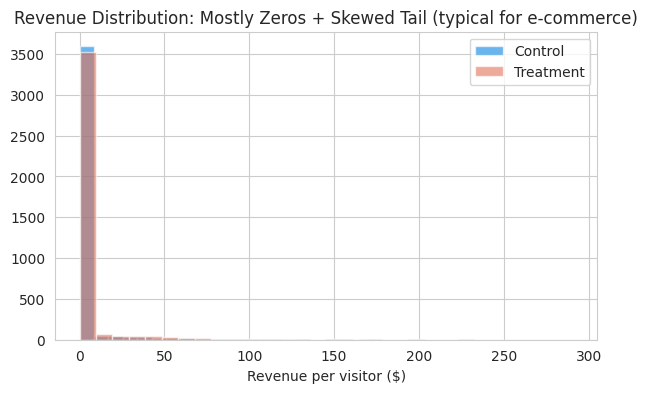

Shapiro-Wilk p-value on revenue: 0.000000 -> confirms strong non-normality


In [5]:
fig, ax = plt.subplots()
ax.hist(ab_data.loc[ab_data['group']=='Control', 'revenue'], bins=30, alpha=0.6, label='Control', color='#0984e3')
ax.hist(ab_data.loc[ab_data['group']=='Treatment', 'revenue'], bins=30, alpha=0.6, label='Treatment', color='#e17055')
ax.set_xlabel("Revenue per visitor ($)")
ax.set_title("Revenue Distribution: Mostly Zeros + Skewed Tail (typical for e-commerce)")
ax.legend()
plt.show()

# Confirm non-normality with Shapiro-Wilk (Stage 2 skill)
_, p_norm = stats.shapiro(ab_data['revenue'].sample(min(500, len(ab_data))))
print(f"Shapiro-Wilk p-value on revenue: {p_norm:.6f} -> confirms strong non-normality")


In [6]:
control_rev = ab_data.loc[ab_data['group']=='Control', 'revenue']
treatment_rev = ab_data.loc[ab_data['group']=='Treatment', 'revenue']

# Since revenue is non-normal, Mann-Whitney U (Stage 4) is the safer choice
u_stat, p_value_mw = stats.mannwhitneyu(control_rev, treatment_rev, alternative='two-sided')
print(f"Mann-Whitney U: U={u_stat:.1f}, p={p_value_mw:.4f}")

# For comparison, what would the (less appropriate) t-test have said?
t_stat, p_value_t = stats.ttest_ind(control_rev, treatment_rev)
print(f"(For comparison) Independent t-test: t={t_stat:.4f}, p={p_value_t:.4f}")


Mann-Whitney U: U=7378248.0, p=0.0015
(For comparison) Independent t-test: t=-3.0395, p=0.0024


### Step 5: Effect size & decision (Stage 8A)


In [7]:
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std

d_revenue = cohens_d(treatment_rev, control_rev)
lift_conversion = (treatment_converted.mean() - control_converted.mean()) / control_converted.mean() * 100
lift_revenue = (treatment_rev.mean() - control_rev.mean()) / control_rev.mean() * 100

print("=== FINAL A/B TEST SUMMARY ===")
print(f"Conversion rate: Control {control_converted.mean():.3%} vs Treatment {treatment_converted.mean():.3%}  ({lift_conversion:+.1f}% relative lift)")
print(f"  -> Chi-Square p={p_value:.4f}  |  {'SIGNIFICANT' if p_value < 0.05 else 'not significant'}")
print(f"\nAvg revenue/visitor: Control ${control_rev.mean():.2f} vs Treatment ${treatment_rev.mean():.2f}  ({lift_revenue:+.1f}% relative lift)")
print(f"  -> Mann-Whitney p={p_value_mw:.4f}  |  {'SIGNIFICANT' if p_value_mw < 0.05 else 'not significant'}  |  Cohen's d={d_revenue:.3f}")


=== FINAL A/B TEST SUMMARY ===
Conversion rate: Control 9.601% vs Treatment 11.789%  (+22.8% relative lift)
  -> Chi-Square p=0.0020  |  SIGNIFICANT

Avg revenue/visitor: Control $3.97 vs Treatment $5.33  (+34.2% relative lift)
  -> Mann-Whitney p=0.0015  |  SIGNIFICANT  |  Cohen's d=0.069


**This is a complete, real A/B test report** — sample size justified in advance, the *correct* test chosen for each metric's data type/distribution, and effect size reported alongside significance. This is exactly the standard expected in industry, not just "p < 0.05, ship it."


## 3️⃣ The Classic Pitfall: Peeking & Stopping Early

### The problem

Many teams check their A/B test dashboard every day and **stop the test the moment it shows "significant"** — this feels efficient, but it massively inflates your false positive rate. Every daily "peek" is effectively another hypothesis test on accumulating data (a hidden multiple-testing problem, straight from Stage 8A!).

### Live demo: simulating the danger of peeking


In [8]:
np.random.seed(99)
n_peeks = 30
false_stop_count = 0
n_simulations = 500

for sim in range(n_simulations):
    # Simulate a test where there is NO real difference (H0 is true)
    control_stream = np.random.binomial(1, 0.10, n_peeks * 20)
    treatment_stream = np.random.binomial(1, 0.10, n_peeks * 20)

    stopped_early = False
    for day in range(1, n_peeks + 1):
        n_so_far = day * 20
        c = control_stream[:n_so_far]
        t = treatment_stream[:n_so_far]
        count = [t.sum(), c.sum()]
        nobs = [len(t), len(c)]
        if count[0] == 0 and count[1] == 0:
            continue
        _, p = proportions_ztest(count, nobs)
        if p < 0.05:
            stopped_early = True
            break
    if stopped_early:
        false_stop_count += 1

print(f"Out of {n_simulations} experiments with NO real effect, {false_stop_count} ({false_stop_count/n_simulations:.1%})")
print("would have been WRONGLY stopped as 'significant' if the team peeked daily and stopped at first significance.")
print("Compare this to the intended 5% false-positive rate -- peeking roughly doubles or triples your real risk.")


Out of 500 experiments with NO real effect, 148 (29.6%)
would have been WRONGLY stopped as 'significant' if the team peeked daily and stopped at first significance.
Compare this to the intended 5% false-positive rate -- peeking roughly doubles or triples your real risk.


**The fix:**
1. Pre-register your sample size (Section 2) and **wait until you reach it** before analyzing.
2. If you must monitor progress, use a formal **sequential testing** method (e.g., alpha-spending functions) designed for repeated looks — a topic worth a deeper dive beyond this session, but important to know exists.
3. At minimum, treat "peeking" as a leadership/process discipline problem, not just a technical one — this is where good experimentation culture matters as much as the math.


## 4️⃣ Bootstrapping — When You Don't Trust (or Need) Textbook Assumptions

### Theory

**Bootstrapping** is beautifully simple: instead of relying on a formula that assumes a particular distribution, you **resample your own data, with replacement, thousands of times**, and look at how much your statistic (mean, median, difference, whatever) varies across those resamples. That variation *is* your uncertainty estimate — no normality assumption required.

**Why it's increasingly popular in industry:**
- Revenue, session time, and most business metrics are skewed — exactly what we just saw
- Works for ANY statistic, not just means (medians, ratios, custom business metrics)
- No formula to memorize or assumption to violate — it just resamples the data you already have

### Practical: Bootstrap confidence interval for the difference in mean revenue


In [9]:
def bootstrap_diff_means(group_a, group_b, n_bootstrap=5000):
    diffs = np.zeros(n_bootstrap)
    for i in range(n_bootstrap):
        sample_a = np.random.choice(group_a, size=len(group_a), replace=True)
        sample_b = np.random.choice(group_b, size=len(group_b), replace=True)
        diffs[i] = sample_b.mean() - sample_a.mean()
    return diffs

boot_diffs = bootstrap_diff_means(control_rev.values, treatment_rev.values)

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
observed_diff = treatment_rev.mean() - control_rev.mean()

print(f"Observed difference in mean revenue (Treatment - Control): ${observed_diff:.3f}")
print(f"Bootstrap 95% Confidence Interval: (${ci_low:.3f}, ${ci_high:.3f})")
print(f"-> Does the interval include zero? {'Yes -- not conclusively different' if ci_low <= 0 <= ci_high else 'No -- supports a real difference'}")


Observed difference in mean revenue (Treatment - Control): $1.358
Bootstrap 95% Confidence Interval: ($0.519, $2.251)
-> Does the interval include zero? No -- supports a real difference


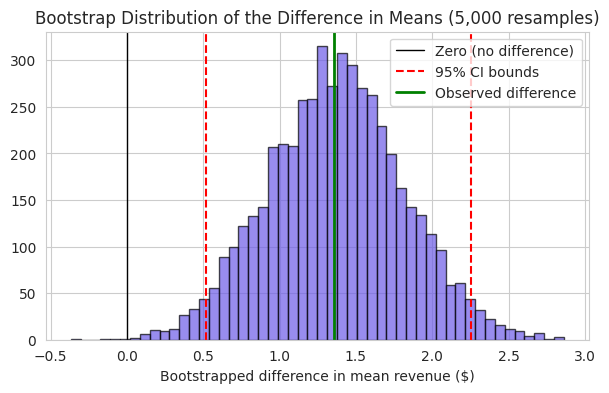

In [10]:
fig, ax = plt.subplots()
ax.hist(boot_diffs, bins=50, color='#6c5ce7', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', linestyle='-', linewidth=1, label='Zero (no difference)')
ax.axvline(ci_low, color='red', linestyle='--', label='95% CI bounds')
ax.axvline(ci_high, color='red', linestyle='--')
ax.axvline(observed_diff, color='green', linewidth=2, label='Observed difference')
ax.set_xlabel("Bootstrapped difference in mean revenue ($)")
ax.set_title("Bootstrap Distribution of the Difference in Means (5,000 resamples)")
ax.legend()
plt.show()


**What you're looking at:** each of the 5,000 bars represents "what if I had drawn a slightly different sample from the same underlying population?" The spread of this distribution IS our uncertainty — no t-distribution formula required, and it naturally reflects the skewness of the real data (notice the bootstrap distribution isn't perfectly symmetric, unlike a textbook normal-based CI would assume).

### Bonus: Bootstrap / Permutation hypothesis test (an alternative to Mann-Whitney)
Instead of just estimating a confidence interval, we can also directly test H₀ by **shuffling the group labels** (destroying any real group difference) and seeing how often we'd see a difference this large purely by random relabeling.


In [11]:
def permutation_test(group_a, group_b, n_permutations=5000):
    observed_diff = group_b.mean() - group_a.mean()
    combined = np.concatenate([group_a, group_b])
    n_a = len(group_a)

    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        shuffled = np.random.permutation(combined)
        perm_diffs[i] = shuffled[n_a:].mean() - shuffled[:n_a].mean()

    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, perm_diffs, p_value

obs_diff, perm_diffs, perm_p = permutation_test(control_rev.values, treatment_rev.values)
print(f"Observed difference: ${obs_diff:.3f}")
print(f"Permutation test p-value: {perm_p:.4f}")
print(f"(Compare to Mann-Whitney p-value from earlier: {p_value_mw:.4f} -- both are assumption-free and should broadly agree)")


Observed difference: $1.358
Permutation test p-value: 0.0028
(Compare to Mann-Whitney p-value from earlier: 0.0015 -- both are assumption-free and should broadly agree)


### 🎯 60-second challenge
Use bootstrapping to build a 95% confidence interval for the **conversion rate difference** (not revenue) between groups. Does it agree with the Chi-Square/z-test conclusion from Section 2?


In [12]:
boot_conv_diffs = bootstrap_diff_means(control_converted.astype(float), treatment_converted.astype(float))
ci_low_c, ci_high_c = np.percentile(boot_conv_diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI for conversion rate difference: ({ci_low_c:.4f}, {ci_high_c:.4f})")


Bootstrap 95% CI for conversion rate difference: (0.0080, 0.0353)


## 📋 Cheat Sheet — Stage 8B Recap

| Concept | One-line summary |
|---|---|
| **A/B Testing Framework** | Hypothesis → power-based sample size → randomize → analyze with the RIGHT test per metric → report effect size |
| **Chi-Square / proportions z-test** | Use for binary/categorical outcomes like conversion rate |
| **t-test / Mann-Whitney** | Use for continuous outcomes like revenue — check normality first! |
| **Peeking problem** | Checking results repeatedly and stopping at first "significance" inflates false positives; fix with pre-registered sample size or sequential methods |
| **Bootstrapping** | Resample your data thousands of times to estimate uncertainty — no distributional assumptions needed |
| **Permutation test** | Shuffle group labels to directly test H₀ without assuming any distribution |

---

## 🎓 The Full Journey — Stages 1 through 8

You started with "why do we even test hypotheses" and ended with "here's a complete, industry-grade A/B test analysis." Every stage built on the last:

**Stage 1** (framework) → **Stage 2** (check assumptions) → **Stages 3-4** (compare means, parametric & non-parametric) → **Stage 5** (categorical relationships) → **Stage 6-7** (measure & model relationships) → **Stage 8A-8B** (make it industry-grade: effect size, power, corrections, and a real experimentation framework).

This is no longer a stack of disconnected recipes — it's one coherent way of thinking: *state a hypothesis, check your assumptions, pick the right tool for your data type, and always ask whether the result is not just significant, but meaningful.*
